c:\Users\Vaibhav Singh\anaconda3\envs\tybsc_practical\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


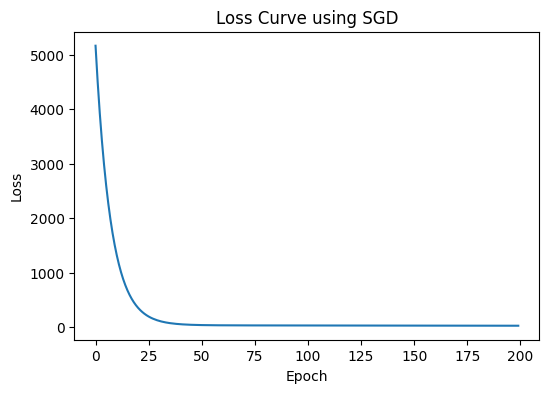

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


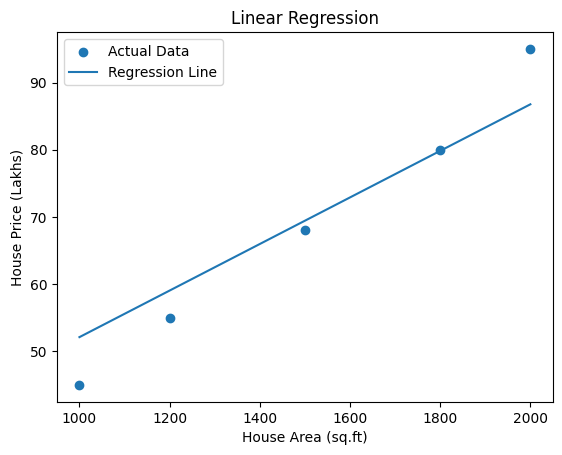

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Predicted Price: [[76.36486]]


In [1]:
# Import TensorFlow library for building and training neural networks
import tensorflow as tf

# Import NumPy for numerical operations and creating arrays
import numpy as np

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt

# ----------------------------------------------------
# STEP 1: Create the Dataset
# ----------------------------------------------------

# Input feature: House area in square feet
X = np.array([1000, 1200, 1500, 1800, 2000], dtype=float)

# Target output: House price in lakhs
Y = np.array([45, 55, 68, 80, 95], dtype=float)

# Normalize the input values by dividing by 1000
# This makes training faster and more stable
X = X / 1000

# ----------------------------------------------------
# STEP 2: Build the Linear Regression Model
# ----------------------------------------------------

# Create a Sequential model
# Sequential means layers are connected one after another
model = tf.keras.Sequential([

    # Add one Dense neuron
    # Dense(1) means one output neuron
    # input_shape=[1] means each training example has one input feature
    tf.keras.layers.Dense(1, input_shape=[1])

])

# ----------------------------------------------------
# STEP 3: Compile the Model
# ----------------------------------------------------

# Configure the learning process
model.compile(

    # SGD (Stochastic Gradient Descent) optimizer updates weights
    optimizer='sgd',

    # Mean Squared Error is used because this is a regression problem
    loss='mse'
)

# ----------------------------------------------------
# STEP 4: Train the Model
# ----------------------------------------------------

# Train the model using training data
history = model.fit(

    # Input values
    X,

    # Output values
    Y,

    # Number of complete passes through the dataset
    epochs=200,

    # verbose=0 hides training output
    verbose=0
)

# ----------------------------------------------------
# STEP 5: Plot Training Loss
# ----------------------------------------------------

# Create a new figure
plt.figure(figsize=(6,4))

# Plot loss values recorded after each epoch
plt.plot(history.history['loss'])

# Title of graph
plt.title("Loss Curve using SGD")

# Label x-axis
plt.xlabel("Epoch")

# Label y-axis
plt.ylabel("Loss")

# Display graph
plt.show()

# ----------------------------------------------------
# STEP 6: Predict Training Data
# ----------------------------------------------------

# Predict prices for all training samples
predictions = model.predict(X)

# ----------------------------------------------------
# STEP 7: Plot Regression Line
# ----------------------------------------------------

# Plot original data points
plt.scatter(X*1000, Y, label="Actual Data")

# Plot predicted regression line
plt.plot(X*1000, predictions, label="Regression Line")

# Label x-axis
plt.xlabel("House Area (sq.ft)")

# Label y-axis
plt.ylabel("House Price (Lakhs)")

# Title of graph
plt.title("Linear Regression")

# Display legend
plt.legend()

# Show graph
plt.show()

# ----------------------------------------------------
# STEP 8: Predict a New House Price
# ----------------------------------------------------

# New house area = 1700 sq.ft
new_area = np.array([1.7])

# Predict price for the new house
predicted_price = model.predict(new_area)

# Print predicted price
print("Predicted Price:", predicted_price)

c:\Users\Vaibhav Singh\anaconda3\envs\tybsc_practical\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


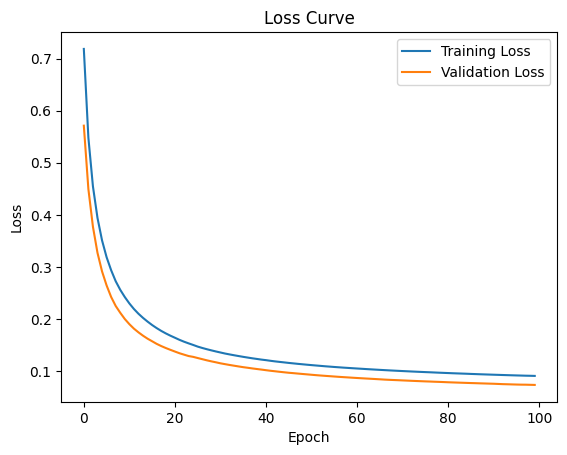

Testing Accuracy: 0.9912280440330505
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
[[0.82972497]
 [0.00113927]
 [0.03927563]
 [0.98155344]
 [0.9973477 ]]
[[ True]
 [False]
 [False]
 [ True]
 [ True]]


In [2]:
# Import TensorFlow library
import tensorflow as tf

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Import Breast Cancer dataset from Scikit-Learn
from sklearn.datasets import load_breast_cancer

# Import function for splitting data
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature normalization
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------
# STEP 1: Load Dataset
# ----------------------------------------------------

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Store input features
X = data.data

# Store target labels
# 0 = Malignant
# 1 = Benign
y = data.target

# ----------------------------------------------------
# STEP 2: Normalize Features
# ----------------------------------------------------

# Create StandardScaler object
scaler = StandardScaler()

# Fit scaler and transform features
X = scaler.fit_transform(X)

# ----------------------------------------------------
# STEP 3: Split Dataset
# ----------------------------------------------------

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(

    # Input features
    X,

    # Output labels
    y,

    # 20% data reserved for testing
    test_size=0.20,

    # Random seed for reproducibility
    random_state=42
)

# ----------------------------------------------------
# STEP 4: Build Logistic Regression Model
# ----------------------------------------------------

# Create Sequential model
model = tf.keras.Sequential([

    # One Dense neuron with Sigmoid activation
    # Sigmoid converts output into probability (0 to 1)
    tf.keras.layers.Dense(

        1,

        activation='sigmoid',

        input_shape=(30,)
    )

])

# ----------------------------------------------------
# STEP 5: Compile Model
# ----------------------------------------------------

model.compile(

    # SGD optimizer updates weights
    optimizer='sgd',

    # Binary Crossentropy is used for binary classification
    loss='binary_crossentropy',

    # Measure classification accuracy
    metrics=['accuracy']
)

# ----------------------------------------------------
# STEP 6: Train Model
# ----------------------------------------------------

history = model.fit(

    # Training input
    X_train,

    # Training output
    y_train,

    # Number of training iterations
    epochs=100,

    # Hide training details
    verbose=0,

    # Validate using testing dataset after every epoch
    validation_data=(X_test, y_test)
)

# ----------------------------------------------------
# STEP 7: Plot Loss Curve
# ----------------------------------------------------

# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Title of graph
plt.title("Loss Curve")

# Label x-axis
plt.xlabel("Epoch")

# Label y-axis
plt.ylabel("Loss")

# Display legend
plt.legend()

# Display graph
plt.show()

# ----------------------------------------------------
# STEP 8: Evaluate Model
# ----------------------------------------------------

# Evaluate model performance using testing data
loss, accuracy = model.evaluate(

    # Testing input
    X_test,

    # Testing output
    y_test,

    # Hide evaluation progress
    verbose=0
)

# Print testing accuracy
print("Testing Accuracy:", accuracy)

# ----------------------------------------------------
# STEP 9: Make Predictions
# ----------------------------------------------------

# Predict probabilities for first five testing samples
predictions = model.predict(X_test[:5])

# Print prediction probabilities
print(predictions)

# ----------------------------------------------------
# STEP 10: Convert Probabilities into Classes
# ----------------------------------------------------

# Convert probability greater than 0.5 to class 1
# Otherwise class 0
predicted_classes = (predictions > 0.5)

# Print predicted classes
print(predicted_classes)